In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
def load_data(filename):
    edges = []
    with open(filename, "r") as file:
        for line in file:
            if line.startswith("#"):
                continue
            src, tgt = map(int, line.strip().split())
            edges.append((src, tgt))
    return np.array(edges)

In [3]:
filename = "wiki-Vote.txt"
edges = load_data(filename)

In [4]:
def compute_degree_distributions(edges):
    in_degree = defaultdict(int)
    out_degree = defaultdict(int)

    for src, tgt in edges:
        out_degree[src] += 1
        in_degree[tgt] += 1

    return in_degree, out_degree

def retrieve_distribution(degree_dict):
    distribution = defaultdict(int)
    for _, degree in degree_dict.items():
        distribution[degree] += 1
    return sorted(distribution.items())

In [5]:
in_degree, out_degree = compute_degree_distributions(edges)
in_degree_dist = retrieve_distribution(in_degree)
out_degree_dist = retrieve_distribution(out_degree)

In [6]:
def plot_degree_distribution(in_degree_dist, out_degree_dist, filename):
    in_degrees, in_freq = zip(*in_degree_dist)
    out_degrees, out_freq = zip(*out_degree_dist)

    plt.figure(figsize=(8, 6))
    plt.loglog(in_degrees, in_freq, 'bo-', label="In-Degree")
    plt.loglog(out_degrees, out_freq, 'ro-', label="Out-Degree")

    plt.xlabel("Degree (k)")
    plt.ylabel("Frequency")
    plt.title("In-Degree and Out-Degree Distribution")
    plt.legend()
    plt.grid(True, which="both", linestyle="--")
    
    plt.savefig(filename)
    plt.show()

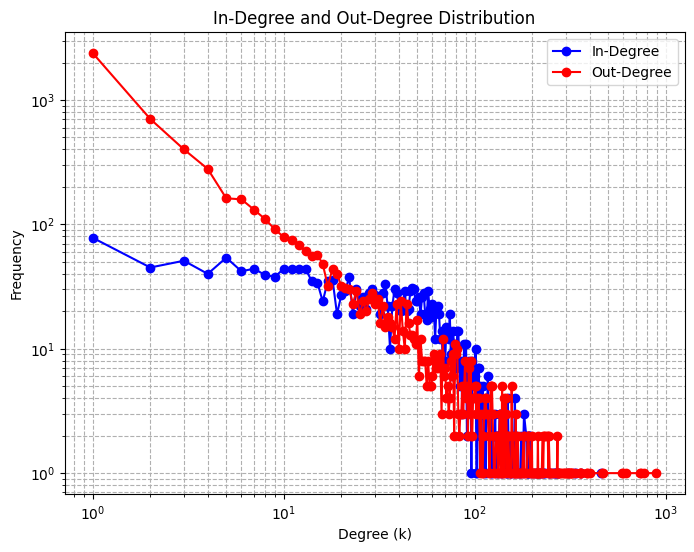

In [7]:
plot_degree_distribution(in_degree_dist, out_degree_dist, "degree_distribution.png")